<a href="https://colab.research.google.com/github/DomingoFox/deep_learning_text_to_speech_comparison/blob/main/text_to_speech_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Text-to-Speech Comparison: AudioLDM2 vs Bark

The focus of the assignment:

- generate repeatable speech samples from the same transcripts,
- save audio outputs for listening tests and presentation demos,
- collect objective metrics for a comparison table,
- keep dependency and import failures explicit instead of hidden.

References:

- https://audioldm.github.io/
- https://huggingface.co/docs/diffusers/api/pipelines/audioldm2

## 1. Dependency Setup

Install the project dependencies once before running the notebook:

```bash
pip install -r requirements.txt
```


In [1]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.2/48.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 93.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.8/103.8 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 115.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 133.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.7/216.7 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 55.8 MB/s eta 0:00:00
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-

In [5]:
!pip install espeakng-loader

In [2]:
import os, random
import warnings
from pathlib import Path
import gc

warnings.filterwarnings("ignore")

OUTPUT_DIR = Path("outputs")
NUMBA_CACHE_DIR = OUTPUT_DIR / "numba_cache"

OUTPUT_DIR.mkdir(exist_ok=True)
NUMBA_CACHE_DIR.mkdir(exist_ok=True)

os.environ.update({
    "HF_HUB_DISABLE_SYMLINKS_WARNING": "1",
    "HF_HUB_DISABLE_PROGRESS_BARS": "0",
    "TRANSFORMERS_VERBOSITY": "warning",
    "MPLBACKEND": "Agg",
    "NUMBA_CACHE_DIR": str(NUMBA_CACHE_DIR.resolve())
})

import espeakng_loader

os.environ["PHONEMIZER_ESPEAK_LIBRARY"] = espeakng_loader.get_library_path()
os.environ["ESPEAK_DATA_PATH"] = espeakng_loader.get_data_path()

import torch
# import torch_directml
import numpy as np
import pandas as pd
import matplotlib
import time
# from tangoflux import TangoFlux

matplotlib.use("Agg", force=True)

import matplotlib.pyplot as plt
from IPython.display import Audio, Image, display

from phonemizer.backend import EspeakBackend
from diffusers import AudioLDM2Pipeline
from diffusers import AudioLDMPipeline

from transformers import AutoProcessor, BarkModel, GPT2Model, ClapModel, ClapProcessor
import librosa, librosa.display
# from tangoflux import TangoFlux, TangoFluxInference

from tts_utils import MetricsCollector, normalize_audio, save_audio


def patch_gpt2_generation():
    def update_model_kwargs(self, outputs, model_kwargs):
        if getattr(outputs, "past_key_values", None) is not None:
            model_kwargs["past_key_values"] = outputs.past_key_values

        if "token_type_ids" in model_kwargs:
            token_type_ids = model_kwargs["token_type_ids"]
            model_kwargs["token_type_ids"] = torch.cat(
                [token_type_ids, token_type_ids[:, -1:]],
                dim=-1
            )

        if "attention_mask" in model_kwargs:
            attention_mask = model_kwargs["attention_mask"]
            model_kwargs["attention_mask"] = torch.cat(
                [attention_mask, attention_mask.new_ones((attention_mask.shape[0], 1))],
                dim=-1
            )

        return model_kwargs

    if not hasattr(GPT2Model, "_update_model_kwargs_for_generation"):
        GPT2Model._update_model_kwargs_for_generation = update_model_kwargs


patch_gpt2_generation()

if not EspeakBackend.is_available():
    raise RuntimeError("AudioLDM2 needs eSpeak NG. Install espeakng-loader or rerun the setup cell.")

print("Imports ready")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Imports ready


## 2. GPU Configuration

In [3]:
REQUIRE_GPU = True
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if not torch.cuda.is_available():
    message = 'CUDA GPU is not available. Install a CUDA-enabled PyTorch build and check the NVIDIA driver.'
    if REQUIRE_GPU:
        raise RuntimeError(message)
    DEVICE = 'cpu'
else:
    DEVICE = 'cuda'
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.empty_cache()
    torch.backends.cuda.matmul.allow_tf32 = True

DTYPE = torch.float16 if DEVICE == 'cuda' else torch.float32

print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA:', torch.version.cuda)
    print('PyTorch:', torch.__version__)

Device: cuda
GPU: Tesla T4
CUDA: 12.8
PyTorch: 2.10.0+cu128


## 3. Experiment Configuration

The notebook starts in smoke-test mode with `MAX_TESTS = 1`, short audio, and low diffusion steps. After the first successful run, will increase `MAX_TESTS`, `AUDIO_LENGTH_IN_S`, and `AUDIOLDM2_STEPS` for final presentation samples.

In [12]:
RUN_AUDIOLDM = True
RUN_AUDIOLDM2 = True
RUN_BARK = True
RUN_TANGOFLUX = True
MAX_TESTS = 1

AUDIO_LENGTH_IN_S = 7.0
AUDIOLDM_STEPS = 10
AUDIOLDM2_STEPS = 10
BARK_MAX_NEW_TOKENS = 220
NUM_WAVEFORMS_PER_PROMPT = 1
NEGATIVE_PROMPT = 'Low quality, distorted, noisy, artifacts.'

AUDIO_LDM_REPO = 'cvssp/audioldm-s-full-v2'
AUDIO_LDM2_REPO = 'anhnct/audioldm2_gigaspeech'
BARK_REPO = 'suno/bark-small'

speech_tests = [
    {
        "id": "short_clear",
        "text": "Good morning. This is a short test of neural text to speech.",
        "type": "neutral"
    },
    {
        "id": "numbers",
        "text": "The experiment uses 3 models, 5 prompts, and 16 kilohertz audio.",
        "type": "technical"
    },
    {
        "id": "academic",
        "text": "Text to speech systems are evaluated by intelligibility, naturalness, latency, and robustness.",
        "type": "academic"
    },
    {
        "id": "longer_sentence",
        "text": "For a fair comparison, every model receives the same sentence, and every generated waveform is saved for listening tests.",
        "type": "long_form"
    }
]

for item in speech_tests:
    # Bark and AudioLDM2 need 'transcript', so we copy 'text' into it
    item['transcript'] = item['text']

    # AudioLDM2 needs 'style', so we turn your 'type' into a descriptive style prompt
    item['style'] = f"A voice speaking clearly in a {item['type']} tone."

# Print one out to verify it has everything!
print("Universal format ready:", speech_tests[0])

pd.DataFrame(speech_tests)

Universal format ready: {'id': 'short_clear', 'text': 'Good morning. This is a short test of neural text to speech.', 'type': 'neutral', 'transcript': 'Good morning. This is a short test of neural text to speech.', 'style': 'A voice speaking clearly in a neutral tone.'}


,id,text,type,transcript,style
0,short_clear,Good morning. This is a short test of neural t...,neutral,Good morning. This is a short test of neural t...,A voice speaking clearly in a neutral tone.
1,numbers,"The experiment uses 3 models, 5 prompts, and 1...",technical,"The experiment uses 3 models, 5 prompts, and 1...",A voice speaking clearly in a technical tone.
2,academic,Text to speech systems are evaluated by intell...,academic,Text to speech systems are evaluated by intell...,A voice speaking clearly in a academic tone.
3,longer_sentence,"For a fair comparison, every model receives th...",long_form,"For a fair comparison, every model receives th...",A voice speaking clearly in a long_form tone.


## 4. Helper Functions

In [5]:
def clear_gpu_memory():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


def to_numpy_audio(audio):
    if isinstance(audio, torch.Tensor):
        audio = audio.detach().cpu().numpy()
    audio = np.asarray(audio).squeeze()
    return normalize_audio(audio.astype(np.float32))


def save_generated_audio(model_name, prompt_id, audio, sr):
    filename = f'{model_name}_{prompt_id}.wav'.replace('/', '_').replace(' ', '_')
    filepath = OUTPUT_DIR / filename
    save_audio(audio, sr, filepath)
    return filepath

## 5. Load Models

The first run downloads large pretrained checkpoints. Later runs reuse the local Hugging Face cache.

In [6]:

def load_audioldm(repo):
    print("Loading AudioLDM:", repo)

    pipe = AudioLDMPipeline.from_pretrained(
        repo,
        torch_dtype=DTYPE
    )

    pipe = pipe.to(DEVICE)
    return pipe

def load_audioldm2():
    print('Loading AudioLDM2:', AUDIO_LDM2_REPO)
    pipe = AudioLDM2Pipeline.from_pretrained(AUDIO_LDM2_REPO, torch_dtype=DTYPE)
    pipe = pipe.to(DEVICE)
    pipe.enable_vae_slicing()
    return pipe

def load_bark():
    print('Loading Bark:', BARK_REPO)
    processor = AutoProcessor.from_pretrained(BARK_REPO)
    # model = BarkModel.from_pretrained(BARK_REPO, dtype=DTYPE)
    model = BarkModel.from_pretrained(BARK_REPO)
    model = model.to(DEVICE)
    # model.enable_cpu_offload()  # offloads parts that can't run on DirectML to CPU automatically
    model.eval()
    return processor, model


# def load_tangoflux():
#     print('Loading TangoFlux:', TANGOFLUX_REPO)

#     from huggingface_hub import hf_hub_download
#     from safetensors.torch import load_file
#     import json

#     # Load config from repo
#     config_path = hf_hub_download(repo_id=TANGOFLUX_REPO, filename="config.json")
#     with open(config_path) as f:
#         config = json.load(f)

#     model = TangoFlux(config)

#     # Load pretrained weights
#     weights_path = hf_hub_download(repo_id=TANGOFLUX_REPO, filename="tangoflux.safetensors")
#     state_dict = load_file(weights_path)
#     model.load_state_dict(state_dict, strict=False)

#     model = model.to(DEVICE)
#     model.eval()
#     return model

# TANGOFLUX_DEVICE = 'cpu'

# def load_tangoflux():
#     print('Loading TangoFlux:', TANGOFLUX_REPO)
#     model = TangoFluxInference(name=TANGOFLUX_REPO, device=TANGOFLUX_DEVICE)
#     return model

model_status = {}

print('Model loader functions are ready. Models are loaded one at a time in the generation cells.')

Model loader functions are ready. Models are loaded one at a time in the generation cells.


## 6. Generate Audio

In [7]:
metrics = MetricsCollector()
generated_rows = []

def run_audioldm_item(pipe, item):
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    start = time.time()

    # FIX: Safely combine whatever text is available (transcript, style, or prompt)
    prompt_text = f"{item.get('transcript', '')} {item.get('style', item.get('prompt', ''))}".strip()

    result = pipe(
        prompt=prompt_text,   # Now strictly a safe string
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=AUDIOLDM_STEPS,
        audio_length_in_s=AUDIO_LENGTH_IN_S,
        num_waveforms_per_prompt=NUM_WAVEFORMS_PER_PROMPT,
        generator=generator
    )

    elapsed = time.time() - start
    audio = to_numpy_audio(result.audios[0])
    return audio, 16000, elapsed

def run_audioldm2_item(pipe, item):
    generator = torch.Generator(device=DEVICE).manual_seed(SEED)
    start = time.time()

    result = pipe(
        prompt=item['style'],
        transcription=item['transcript'],
        negative_prompt=NEGATIVE_PROMPT,
        num_inference_steps=AUDIOLDM2_STEPS,
        audio_length_in_s=AUDIO_LENGTH_IN_S,
        num_waveforms_per_prompt=NUM_WAVEFORMS_PER_PROMPT,
        generator=generator,
        max_new_tokens=512
    )

    elapsed = time.time() - start
    audio = to_numpy_audio(result.audios[0])
    return audio, 16000, elapsed

def run_bark_item(processor, model, item):
    # Bark generates pure TTS, so we only feed it the transcript.
    # Fallback to 'prompt' in case you accidentally feed it a sound effect test.
    text_input = item.get('transcript', item.get('prompt', ''))

    inputs = processor(text_input, voice_preset='v2/en_speaker_6', return_tensors='pt')
    inputs = {key: value.to(DEVICE) for key, value in inputs.items()}

    start = time.time()
    with torch.no_grad():
        audio = model.generate(**inputs, semantic_max_new_tokens=BARK_MAX_NEW_TOKENS)

    elapsed = time.time() - start
    sr = model.generation_config.sample_rate
    audio = to_numpy_audio(audio)
    return audio, sr, elapsed

def run_tangoflux_item(model, item):
    start = time.time()
    audio = model.generate(
        prompt=item['style'],
        steps=50,
        duration=AUDIO_LENGTH_IN_S,
        guidance_scale=3.5,
    )
    elapsed = time.time() - start
    audio = to_numpy_audio(audio)
    return audio, 44100, elapsed  # TangoFlux uses 44100 sample rat

def record_result(model_name, item, audio, sr, elapsed):
    filepath = save_generated_audio(model_name, item['id'], audio, sr)
    metrics.add_model_result(model_name, item['id'], elapsed, audio, sr)

    generated_rows.append({
        'model': model_name,
        'prompt_id': item['id'],
        # FIX: Use .get() here so sound_tests don't crash the logger!
        'transcript': item.get('transcript', ''),
        'style': item.get('style', item.get('prompt', '')),
        'seconds': round(elapsed, 2),
        'sample_rate': sr,
        'file': str(filepath)
    })

    print(f'{model_name} | {item["id"]}: {elapsed:.1f}s -> {filepath}')

In [13]:
if RUN_AUDIOLDM:

    audioldm_pipe = None

    try:
        audioldm_pipe = load_audioldm(AUDIO_LDM_REPO)
        model_status['AudioLDM'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:

            audio, sr, elapsed = run_audioldm_item(
                audioldm_pipe,
                item
            )

            record_result(
                'AudioLDM',
                item,
                audio,
                sr,
                elapsed
            )

    except Exception as error:
        model_status['AudioLDM'] = str(error)
        print('AudioLDM failed:', error)

    finally:
        del audioldm_pipe
        clear_gpu_memory()

Loading AudioLDM: cvssp/audioldm-s-full-v2


model_index.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The AudioLDMPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


  0%|          | 0/10 [00:00<?, ?it/s]

AudioLDM | short_clear: 2.6s -> outputs/AudioLDM_short_clear.wav


In [14]:
if RUN_AUDIOLDM2:
    audioldm2_pipe = None
    try:
        audioldm2_pipe = load_audioldm2()
        model_status['AudioLDM2'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:
            # ADD THIS PRINT TO DEBUG THE DATA:
            print("Currently processing:", item)

            audio, sr, elapsed = run_audioldm2_item(audioldm2_pipe, item)
            record_result('AudioLDM2', item, audio, sr, elapsed)

    except Exception as error:
        model_status['AudioLDM2'] = str(error)
        print('AudioLDM2 failed:', error)

    finally:
        del audioldm2_pipe
        clear_gpu_memory()

Loading AudioLDM2: anhnct/audioldm2_gigaspeech


model_index.json:   0%|          | 0.00/798 [00:00<?, ?B/s]

Fetching 27 files:   0%|          | 0/27 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/11 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--anhnct--audioldm2_gigaspeech/snapshots/c812a7861f38a69441a8e0428438e782d9864614/projection_model: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--anhnct--audioldm2_gigaspeech/snapshots/c812a7861f38a69441a8e0428438e782d9864614/projection_model.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--anhnct--audioldm2_gigaspeech/snapshots/c812a7861f38a69441a8e0428438e782d9864614/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--anhnct--audioldm2_gigaspeech/snapshots/c812a7861f38a69441a8e0428438e782d9864614/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Expected types for language_model: (<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>,), got <class 'transformers.models.gpt2.modeling_gpt2.GPT2Model'>.


Currently processing: {'id': 'short_clear', 'text': 'Good morning. This is a short test of neural text to speech.', 'type': 'neutral', 'transcript': 'Good morning. This is a short test of neural text to speech.', 'style': 'A voice speaking clearly in a neutral tone.'}


  0%|          | 0/10 [00:00<?, ?it/s]

AudioLDM2 | short_clear: 12.9s -> outputs/AudioLDM2_short_clear.wav


In [15]:
if RUN_BARK:
    bark_processor = None
    bark_model = None
    try:
        bark_processor, bark_model = load_bark()
        model_status['Bark'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:
            audio, sr, elapsed = run_bark_item(bark_processor, bark_model, item)
            record_result('Bark', item, audio, sr, elapsed)
    except Exception as error:
        model_status['Bark'] = str(error)
        print('Bark failed:', error)
    finally:
        del bark_model
        del bark_processor
        clear_gpu_memory()

Loading Bark: suno/bark-small


tokenizer_config.json:   0%|          | 0.00/353 [00:00<?, ?B/s]

speaker_embeddings_path.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

speaker_embeddings/v2/en_speaker_6_seman(…):   0%|          | 0.00/2.60k [00:00<?, ?B/s]

speaker_embeddings/v2/en_speaker_6_coars(…):   0%|          | 0.00/7.55k [00:00<?, ?B/s]

speaker_embeddings/v2/en_speaker_6_fine_(…):   0%|          | 0.00/15.0k [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'min_eos_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Passing `

Bark | short_clear: 16.0s -> outputs/Bark_short_clear.wav


In [ ]:
if RUN_TANGOFLUX:
    tangoflux_model = None
    try:
        tangoflux_model = load_tangoflux()
        model_status['TangoFlux'] = 'ready'

        for item in speech_tests[:MAX_TESTS]:
            audio, sr, elapsed = run_tangoflux_item(tangoflux_model, item)
            record_result('TangoFlux', item, audio, sr, elapsed)
    except Exception as error:
        model_status['TangoFlux'] = str(error)
        print('TangoFlux failed:', error)
    finally:
        del tangoflux_model
        clear_gpu_memory()

Loading TangoFlux: declare-lab/TangoFlux


Fetching 11 files:   0%|          | 0/11 [00:00<?, ?it/s]

 92%|█████████▏| 46/50 [09:41<00:50, 12.69s/it]

## 7. Listen to Generated Samples

Use these audio controls for subjective evaluation. For the presentation, pick the clearest examples and include both the metric table and short listening clips.

In [16]:
generated_df = pd.DataFrame(generated_rows)

if generated_df.empty:
    print('No audio was generated. Check model_status above.')
else:
    display(generated_df[['model', 'prompt_id', 'seconds', 'sample_rate', 'file']])

    for row in generated_rows:
        print(row['model'], '|', row['prompt_id'], '|', row['transcript'])
        display(Audio(row['file']))

,model,prompt_id,seconds,sample_rate,file
0,AudioLDM,short_clear,2.57,16000,outputs/AudioLDM_short_clear.wav
1,AudioLDM2,short_clear,12.93,16000,outputs/AudioLDM2_short_clear.wav
2,Bark,short_clear,16.00,24000,outputs/Bark_short_clear.wav


AudioLDM | short_clear | Good morning. This is a short test of neural text to speech.


AudioLDM2 | short_clear | Good morning. This is a short test of neural text to speech.


Bark | short_clear | Good morning. This is a short test of neural text to speech.


## 8. Objective Metrics

These metrics do not replace human listening. They are useful for reproducible comparison and presentation tables:

- inference time: practical speed,
- duration: generated waveform length,
- loudness: RMS energy,
- spectral centroid: brightness,
- zero crossing rate: noisiness indicator,
- temporal variance: rough activity/dynamics indicator.
- CLAP
- UTMOS

### 8.1. CLAP

In [17]:
CLAP_REPO = "laion/clap-htsat-unfused"

def load_clap():
    print("Loading CLAP model...")
    processor = ClapProcessor.from_pretrained(CLAP_REPO)
    model = ClapModel.from_pretrained(CLAP_REPO)
    model.eval()
    return processor, model

def compute_clap_score(processor, model, text_prompt, audio_path, sample_rate=48000):
    """
    Computes cosine similarity between a text prompt and audio file using CLAP.
    Returns a score between -1 and 1, higher is better.
    """
    # Load audio from disk and resample to 48kHz (CLAP requirement)
    audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)

    # Process text and audio
    inputs = processor(
        text=[text_prompt],
        audio=[audio],
        sampling_rate=sample_rate,
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():
        # FIX: Pass inputs directly into the model to get the clean projected tensors
        outputs = model(**inputs)

        # Extract the pre-projected tensor embeddings from the outputs object
        text_embeds = outputs.text_embeds
        audio_embeds = outputs.audio_embeds

    # Normalize embeddings
    text_embeds = text_embeds / text_embeds.norm(dim=-1, keepdim=True)
    audio_embeds = audio_embeds / audio_embeds.norm(dim=-1, keepdim=True)

    # Cosine similarity
    score = (text_embeds * audio_embeds).sum(dim=-1).item()
    return score

def evaluate_all_clap_scores(processor, model, speech_tests, output_dir="outputs"):
    """
    Automatically matches saved wav files to their prompts and computes CLAP scores.
    Expects files named like: outputs/ModelName_test_id.wav
    """
    scores = []

    # Find all wav files in output directory
    wav_files = [f for f in os.listdir(output_dir) if f.endswith(".wav")]

    for wav_file in wav_files:
        # Parse model name and test id from filename e.g. "AudioLDM2_short_clear.wav"
        name = wav_file.replace(".wav", "")
        parts = name.split("_", 1)  # split on first underscore only
        # print(name.split("_", 1))
        if len(parts) != 2:
            print(f"Skipping {wav_file} - unexpected filename format")
            continue

        model_name, test_id = parts

        # Find matching test item
        test_item = next((t for t in speech_tests if t["id"] == test_id), None)
        if test_item is None:
            print(f"Skipping {wav_file} - no matching test id '{test_id}'")
            continue

        audio_path = os.path.join(output_dir, wav_file)
        score = compute_clap_score(processor, model, test_item["transcript"], audio_path)

        scores.append({
            "model": model_name,
            "test_id": test_id,
            "prompt": test_item["transcript"],
            "style": test_item["style"],
            "clap_score": round(score, 4),
            "audio_path": audio_path
        })
        print(f"[{model_name}] [{test_id}] CLAP Score: {score:.4f}")

    return scores

# Run it

clap_processor, clap_model = load_clap()
clap_scores = evaluate_all_clap_scores(clap_processor, clap_model, speech_tests)

clap_lookup = {(s["model"], s["test_id"]): s["clap_score"] for s in clap_scores}

Loading CLAP model...


preprocessor_config.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/615M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

[AudioLDM2] [short_clear] CLAP Score: 0.2265
[Bark] [short_clear] CLAP Score: 0.2163
[AudioLDM] [short_clear] CLAP Score: 0.3783


### 8.2 UTMOS Prediction

In [42]:
def load_utmos():
    print("Loading UTMOS model...")
    utmos_model = torch.hub.load(
        "tarepan/SpeechMOS:v1.2.0",
        "utmos22_strong",
        trust_repo=True
    )
    utmos_model.eval()
    return utmos_model

def compute_utmos_score(model, audio_path, sample_rate=16000):
    """
    Computes UTMOS MOS prediction score for a given audio file.
    Returns a score between 1-5, higher is better.
    """
    # UTMOS requires 16kHz mono audio
    audio, sr = librosa.load(audio_path, sr=sample_rate, mono=True)
    audio_tensor = torch.tensor(audio).unsqueeze(0)  # add batch dimension

    with torch.no_grad():
        score = model(audio_tensor, sample_rate)

    return score.item()

def evaluate_all_utmos_scores(model, speech_tests, output_dir="outputs"):
    """
    Automatically matches saved wav files to their test ids and computes UTMOS scores.
    Expects files named like: outputs/ModelName_test_id.wav
    """
    scores = []

    wav_files = [f for f in os.listdir(output_dir) if f.endswith(".wav")]

    for wav_file in wav_files:
        name = wav_file.replace(".wav", "")
        parts = name.split("_", 1)
        if len(parts) != 2:
            print(f"Skipping {wav_file} - unexpected filename format")
            continue

        model_name, test_id = parts

        test_item = next((t for t in speech_tests if t["id"] == test_id), None)
        if test_item is None:
            print(f"Skipping {wav_file} - no matching test id '{test_id}'")
            continue

        audio_path = os.path.join(output_dir, wav_file)
        score = compute_utmos_score(model, audio_path)

        scores.append({
            "model": model_name,
            "test_id": test_id,
            "utmos_score": round(score, 4),
            "audio_path": audio_path
        })
        print(f"[{model_name}] [{test_id}] UTMOS Score: {score:.4f}")

    return scores

# Run it
utmos_model = load_utmos()
utmos_scores = evaluate_all_utmos_scores(utmos_model, speech_tests)

utmos_lookup = {(s["model"], s["test_id"]): s["utmos_score"] for s in utmos_scores}

Loading UTMOS model...


Using cache found in /root/.cache/torch/hub/tarepan_SpeechMOS_v1.2.0


NameError: name 'wav_path' is not defined

## 9. Model Intermediate Performances table

In [43]:
def build_intermediate_results(speech_tests, clap_scores, utmos_scores, metrics,utmos_model=None, output_dir="outputs"):
    """
    Builds a per-wav-file results dataframe with all metrics.
    """
    rows = []
    wav_files = [f for f in os.listdir(output_dir) if f.endswith(".wav")]

    # Build lookups
    clap_lookup  = {(s["model"], s["test_id"]): s["clap_score"]  for s in clap_scores}
    utmos_lookup = {(s["model"], s["test_id"]): s["utmos_score"] for s in utmos_scores}

    # Warn early if UTMOS is missing
    if not utmos_lookup:
        print("⚠️  WARNING: utmos_scores is empty — UTMOS column will be blank.")
        print("   Make sure evaluate_all_utmos_scores() ran successfully before this function.")

    for wav_file in wav_files:
        name = wav_file.replace(".wav", "")
        parts = name.split("_", 1)
        if len(parts) != 2:
            continue

        model_name, test_id = parts

        test_item = next((t for t in speech_tests if t["id"] == test_id), None)
        if test_item is None:
            continue

        item_metrics = next(
            (r for r in metrics.results.get(model_name, []) if r.get("prompt") == test_id),
            {}
        )

        inference_time = item_metrics.get("inference_time")
        duration       = item_metrics.get("duration")
        rtf = round(inference_time / duration, 4) if inference_time and duration and duration > 0 else None

        # Try lookup first; fall back to computing inline from the wav file
        utmos_score = utmos_lookup.get((model_name, test_id))
        if utmos_score is None:
            try:
                wav_path = os.path.join(output_dir, wav_file)
                utmos_score = compute_utmos_score(utmos_model, wav_path, sample_rate=24000)
            except Exception as e:
                print(f"  UTMOS failed for {wav_file}: {e}")
                utmos_score = None

        rows.append({
            "Model":              model_name,
            "Test ID":            test_id,
            "Transcript":         test_item["transcript"],
            "Style":              test_item["style"],
            "Audio File":         wav_file,
            "Inference Time (s)": round(inference_time, 4) if inference_time else None,
            "Duration (s)":       round(duration, 4)       if duration       else None,
            "RTF":                rtf,
            "Loudness":           round(item_metrics["loudness"],          4) if "loudness"          in item_metrics else None,
            "Spectral Centroid":  round(item_metrics["spectral_centroid"], 2) if "spectral_centroid" in item_metrics else None,
            "Zero Crossing Rate": round(item_metrics["zero_crossing_rate"],4) if "zero_crossing_rate"in item_metrics else None,
            "Temporal Variance":  round(item_metrics["temporal_variance"], 4) if "temporal_variance" in item_metrics else None,
            "CLAP Score":         clap_lookup.get((model_name, test_id)),
            "UTMOS Score":        round(utmos_score, 4) if utmos_score is not None else None,
        })

    df = pd.DataFrame(rows).sort_values(["Model", "Test ID"]).reset_index(drop=True)
    save_path = OUTPUT_DIR / "intermediate_results.csv"
    df.to_csv(save_path, index=False)
    print(f"Saved: {save_path} ({len(df)} rows, UTMOS populated: {df['UTMOS Score'].notna().sum()}/{len(df)})")
    return df

# Run it
intermediate_df = build_intermediate_results(speech_tests, clap_scores, utmos_scores, metrics)

Saved: outputs/intermediate_results.csv (3 rows, UTMOS populated: 3/3)


## 10. Model Performance Summary

In [20]:
summary_rows = []

for model_name in metrics.results:
    summary = metrics.get_summary(model_name)

    # Average CLAP, UTMOS, DNSMOS scores across all test ids for this model
    model_clap_scores = [v for (m, t), v in clap_lookup.items() if m == model_name]
    avg_clap = round(sum(model_clap_scores) / len(model_clap_scores), 4) if model_clap_scores else None

    model_utmos_scores = [v for (m, t), v in utmos_lookup.items() if m == model_name]
    avg_utmos = round(sum(model_utmos_scores) / len(model_utmos_scores), 4) if model_utmos_scores else None

    # RTF = inference_time / audio_duration, lower is better
    avg_inference = summary['avg_inference_time']
    avg_duration = summary['avg_duration']
    rtf = round(avg_inference / avg_duration, 4) if avg_duration > 0 else None

    summary_rows.append({
        'Model': model_name,
        'Inference Time (s)': round(summary['avg_inference_time'], 2),
        'Duration (s)': round(summary['avg_duration'], 2),
        'RTF': rtf,  # <1 means faster than real-time, >1 means slower
        'Loudness': round(summary['avg_loudness'], 4),
        'Spectral Centroid': round(summary['avg_spectral_centroid'], 2),
        'Zero Crossing Rate': round(summary['avg_zero_crossing_rate'], 4),
        'Temporal Variance': round(summary['avg_temporal_variance'], 4),
        'CLAP Score': avg_clap,
        'UTMOS Score': avg_utmos
    })

summary_df = pd.DataFrame(summary_rows)

if summary_df.empty:
    print('No metrics available.')
else:
    display(summary_df)
    summary_df.to_csv(OUTPUT_DIR / 'comparison_results.csv', index=False)
    generated_df.to_csv(OUTPUT_DIR / 'generated_audio_index.csv', index=False)

,Model,Inference Time (s),Duration (s),RTF,Loudness,Spectral Centroid,Zero Crossing Rate,Temporal Variance,CLAP Score,UTMOS Score
0,AudioLDM,2.57,7.0,0.3671,0.1304,2125.30,0.0387,0.4602,0.3783,1.2463
1,AudioLDM2,12.93,7.0,1.8476,0.4284,1552.21,0.0839,0.1478,0.2265,1.2930
2,Bark,16.00,4.4,3.6355,0.1029,1394.32,0.0659,0.1913,0.2163,2.9922


## 9. Mel Spectrograms for comparison

In [23]:
def plot_mel_spectrograms(speech_tests, model_names, output_dir="outputs", test_id=None):
    """
    Plots mel spectrograms for the same test_id across all models side by side.
    If test_id is None, picks one randomly.
    """
    # Pick a random test_id if not specified
    if test_id is None:
        test_id = random.choice(speech_tests)["id"]

    print(f"Plotting mel spectrograms for test: '{test_id}'")

    # Find wav files for this test_id across all models
    audio_files = {}
    for model_name in model_names:
        path = os.path.join(output_dir, f"{model_name}_{test_id}.wav")
        if os.path.exists(path):
            audio_files[model_name] = path
        else:
            print(f"Warning: {path} not found, skipping {model_name}")

    if not audio_files:
        print("No audio files found for this test_id.")
        return

    n_models = len(audio_files)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))
    if n_models == 1:
        axes = [axes]

    for ax, (model_name, audio_path) in zip(axes, audio_files.items()):
        audio, sr = librosa.load(audio_path, sr=None, mono=True)
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=128, fmax=8000)
        mel_db = librosa.power_to_db(mel, ref=np.max)

        img = librosa.display.specshow(mel_db, sr=sr, x_axis="time", y_axis="mel", fmax=8000, ax=ax)
        ax.set_title(f"{model_name}\n({test_id})", fontsize=12)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Frequency (Hz)")
        fig.colorbar(img, ax=ax, format="%+2.0f dB")

    plt.suptitle(f"Mel Spectrogram Comparison — '{test_id}'", fontsize=14, y=1.02)
    plt.tight_layout()

    # Save the plot
    save_path = os.path.join(output_dir, f"mel_spectrogram_{test_id}.png")
    plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()
    print(f"Saved: {save_path}")

# Run it — picks a random test_id
plot_mel_spectrograms(
    speech_tests=speech_tests,
    model_names=["AudioLDM", "AudioLDM2", "Bark"],  # adjust to your model names
    output_dir="outputs"
)

# Or specify a specific test_id
# plot_mel_spectrograms(speech_tests, ["AudioLDM2", "Bark"], test_id="short_clear")

Plotting mel spectrograms for test: 'short_clear'
Saved: outputs/mel_spectrogram_short_clear.png


## 10. Summary Graphs

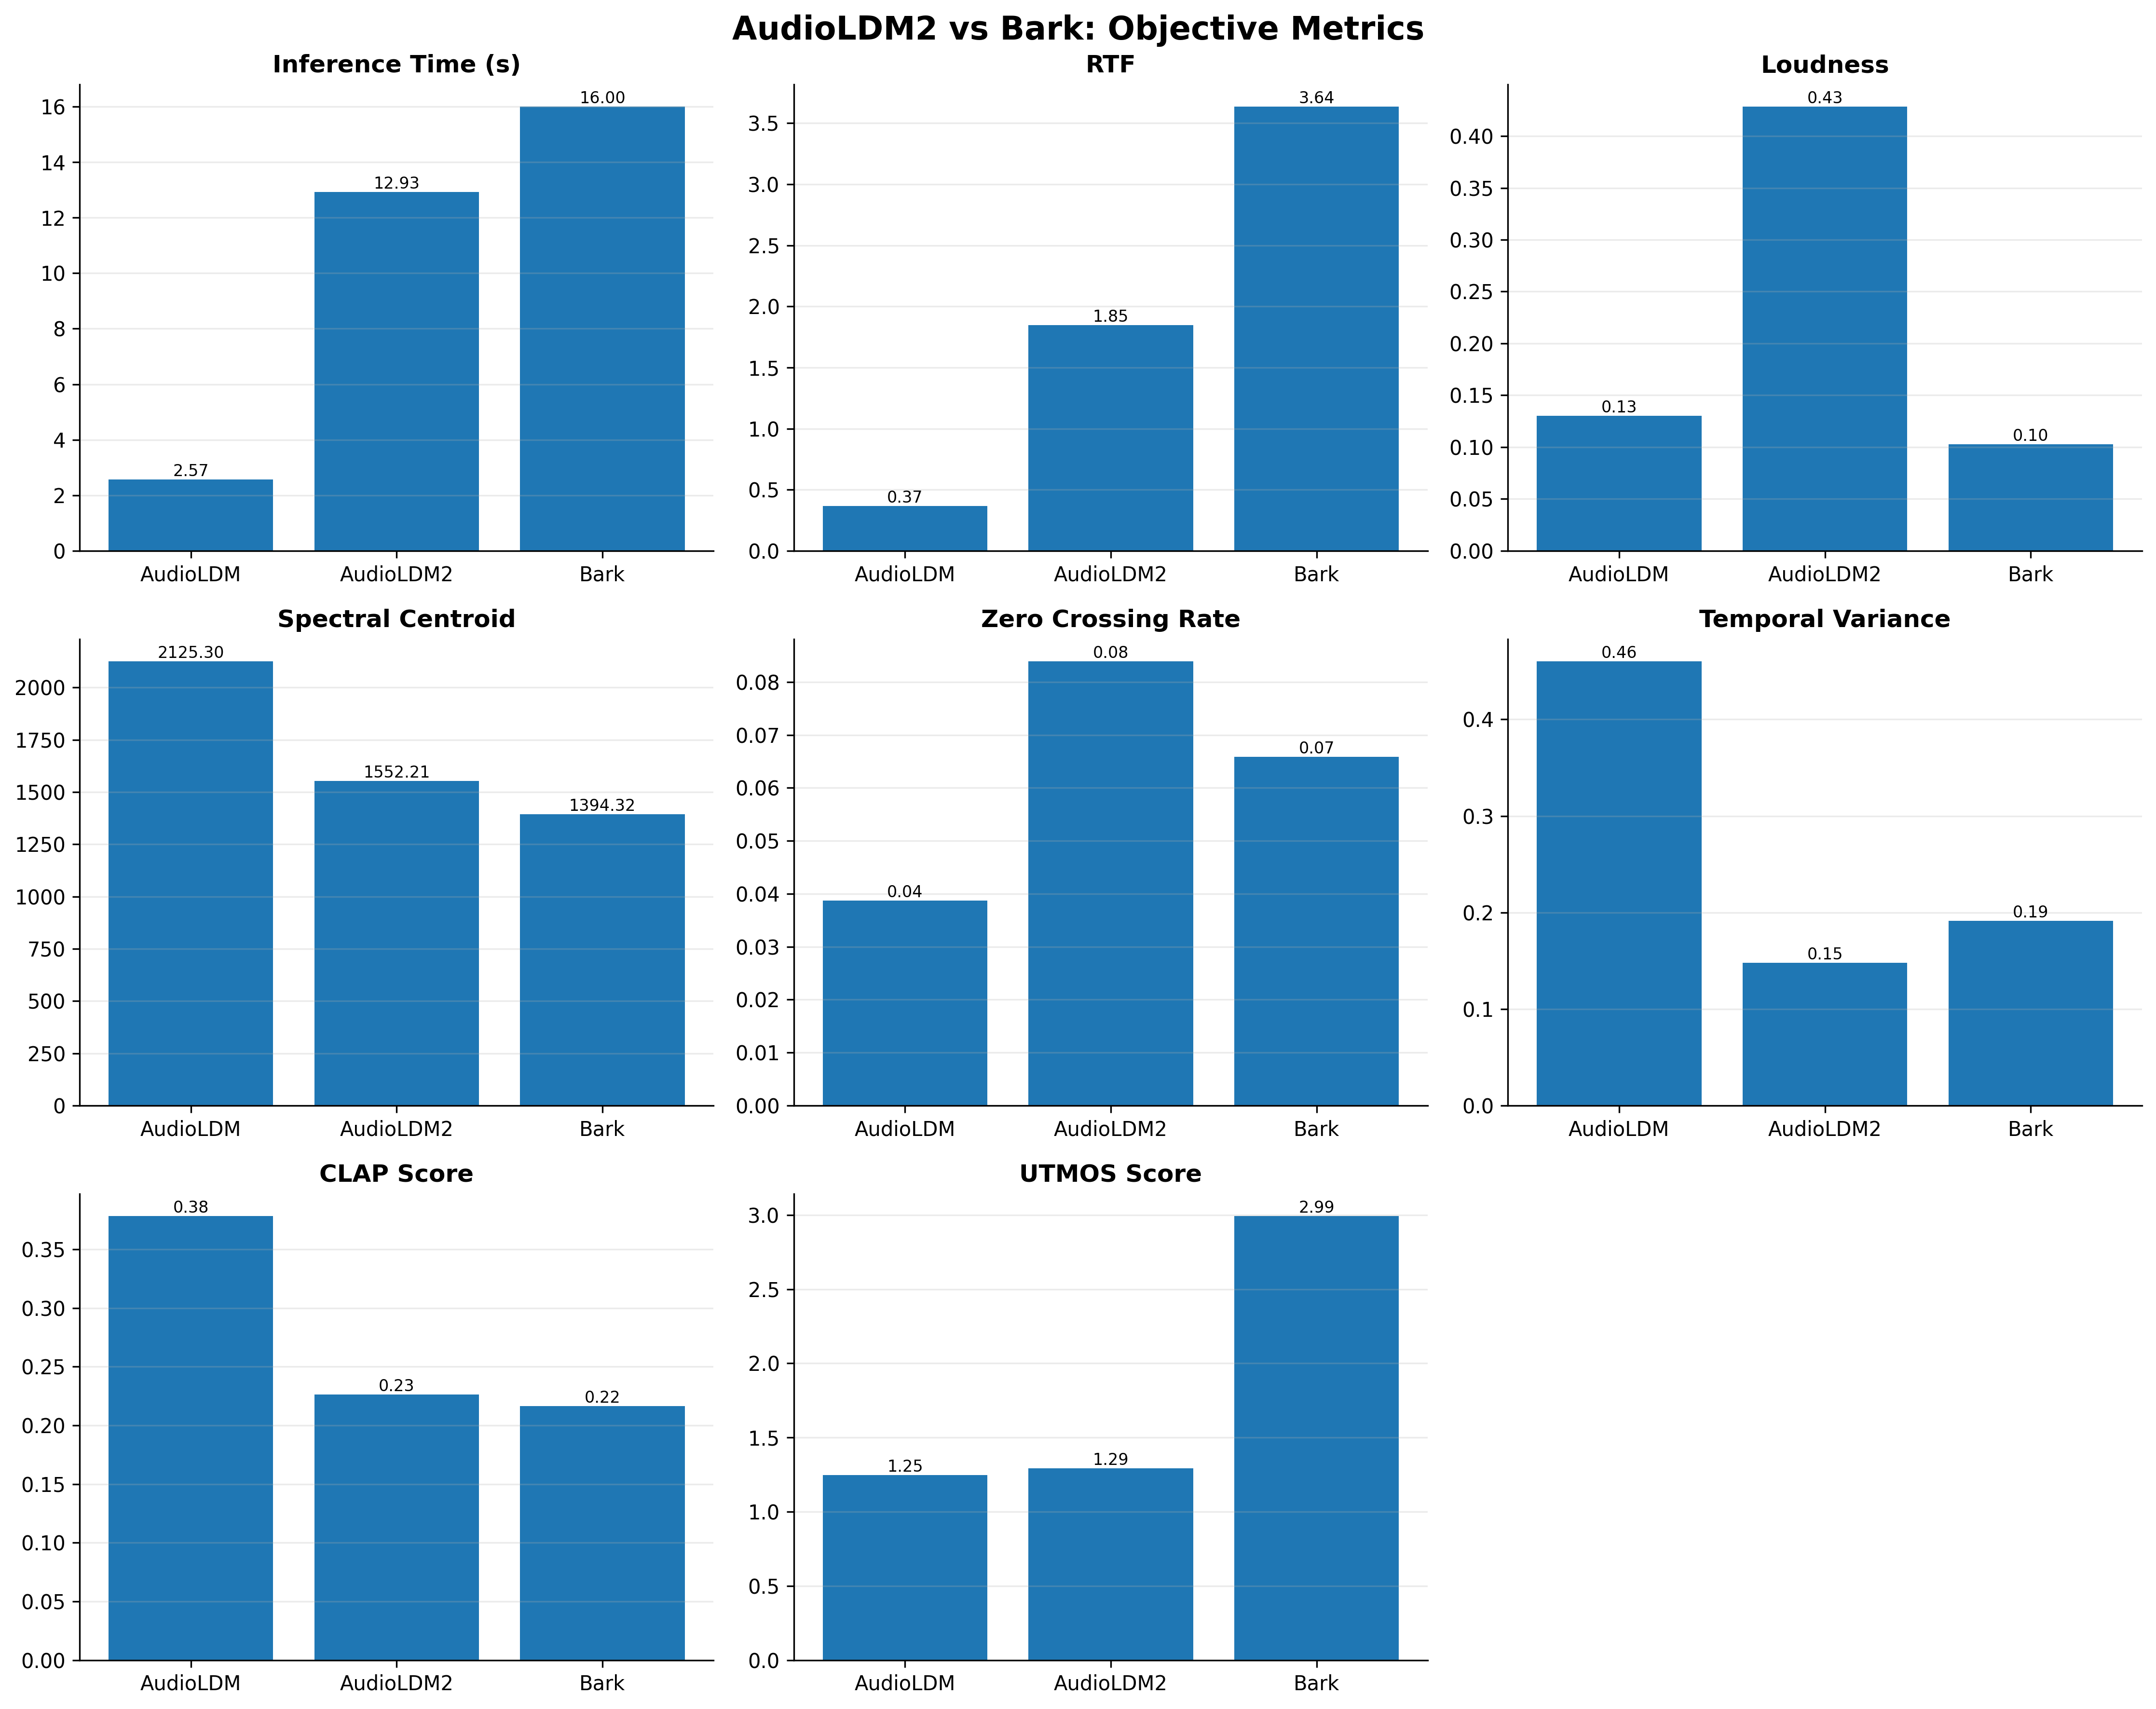

In [24]:
if not summary_df.empty:
    plot_df = summary_df.set_index("Model").drop(columns=["Duration (s)"], errors="ignore")

    n_cols = 3
    n_rows = int(np.ceil(len(plot_df.columns) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = np.ravel(axes)

    for ax, column in zip(axes, plot_df.columns):
        values = plot_df[column]
        bars = ax.bar(values.index, values.values)

        ax.set_title(column, weight="bold")
        ax.grid(axis="y", alpha=0.25)
        ax.spines[["top", "right"]].set_visible(False)

        for bar in bars:
            value = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    for ax in axes[len(plot_df.columns):]:
        ax.axis("off")

    fig.suptitle("AudioLDM2 vs Bark: Objective Metrics", fontsize=16, weight="bold")
    fig.tight_layout()

    plot_path = OUTPUT_DIR / "comparison_metrics.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    display(Image(filename=str(plot_path)))

## 11. Save Results

In [25]:
metrics.save_results(OUTPUT_DIR / 'detailed_metrics.json')

print('Saved files:')
for filepath in sorted(OUTPUT_DIR.glob('*')):
    print(filepath)

Saved files:
outputs/AudioLDM2_short_clear.wav
outputs/AudioLDM_short_clear.wav
outputs/Bark_short_clear.wav
outputs/comparison_metrics.png
outputs/comparison_results.csv
outputs/detailed_metrics.json
outputs/generated_audio_index.csv
outputs/intermediate_results.csv
outputs/mel_spectrogram_short_clear.png
outputs/numba_cache


In [27]:
speech_tests_extreme = [
    # --- Extreme Pacing & Cadence ---
    {
        "id": "auctioneer_fast",
        "transcript": "Do I hear fifty? Fifty dollars to the gentleman in the back, now sixty, sixty dollars, going once, going twice, sold for sixty dollars!",
        "style": "A male auctioneer speaking at breakneck speed, rhythmic, continuous, and highly energetic."
    },
    {
        "id": "hypnotist_slow",
        "transcript": "Your eyelids are becoming incredibly heavy. With every word I speak, you sink deeper, and deeper, into relaxation.",
        "style": "A woman speaking extremely slowly, with a smooth, soothing, and rhythmic cadence."
    },
    {
        "id": "out_of_breath",
        "transcript": "I ran... all the way here... I think we lost them... back at the bridge.",
        "style": "A young man speaking while panting heavily, out of breath, and struggling to finish the sentence."
    },
    {
        "id": "valley_girl_upspeak",
        "transcript": "So I was literally just walking down the street? And this guy comes up to me? And it was, like, totally bizarre?",
        "style": "A young woman speaking with heavy vocal fry and upspeak, making every statement sound like a question."
    },
    {
        "id": "stuttering_nervous",
        "transcript": "I... I-I didn't mean to do it. It was a... it was an accident, I swear!",
        "style": "A young boy stuttering heavily, his voice trembling with severe anxiety."
    },

    # --- Professions & Archetypes ---
    {
        "id": "drill_sergeant",
        "transcript": "Drop down and give me fifty right now! I want to see sweat hitting the dirt!",
        "style": "A middle-aged man screaming with intense, raspy, drill-sergeant authority."
    },
    {
        "id": "asmr_whisper",
        "transcript": "I am going to tap on this glass very gently. Listen closely to the sound it makes.",
        "style": "A young woman speaking in an extremely close, breathy, and gentle ASMR whisper."
    },
    {
        "id": "epic_movie_trailer",
        "transcript": "In a world where magic has been outlawed, one man must risk everything to save his family.",
        "style": "A man with an incredibly deep, gravelly, and dramatic cinematic voice."
    },
    {
        "id": "standup_comedian",
        "transcript": "So the doctor says to me, 'you have five months to live,' and I said, 'doc, can I get a second opinion?'",
        "style": "A middle-aged woman speaking loudly with punchy, comedic timing, sounding like she is on stage."
    },
    {
        "id": "flight_attendant",
        "transcript": "Please ensure your seatbelts are securely fastened and your tray tables are in their full upright position.",
        "style": "A young female speaking with an overly cheerful, crisp, and rehearsed customer service singsong."
    },

    # --- Extreme Emotions ---
    {
        "id": "devastated_crying",
        "transcript": "I can't believe they are really gone. What am I supposed to do now?",
        "style": "An adult male sobbing, his voice cracking and breaking with profound grief."
    },
    {
        "id": "manic_laughter",
        "transcript": "It works! I finally fixed the formula! They said I was crazy, but look at it now!",
        "style": "An older man speaking frantically, bursting into manic, unstable laughter."
    },
    {
        "id": "terrified_whisper",
        "transcript": "Turn the flashlight off. It can see the light.",
        "style": "A young woman whispering with absolute dread and terror in her voice."
    },
    {
        "id": "furious_karen",
        "transcript": "I demand to speak to your manager right this second! This is completely unacceptable!",
        "style": "A middle-aged woman shouting loudly with extreme entitlement, sharpness, and anger."
    },
    {
        "id": "deep_depression",
        "transcript": "It just doesn't matter anymore. Nothing I do makes any difference.",
        "style": "A teenage boy speaking with absolutely zero energy, flat, monotone, and defeated."
    },

    # --- Quirky & Unusual Scenarios ---
    {
        "id": "teeth_chattering",
        "transcript": "I-it is so c-cold out here, I can't f-feel my fingers.",
        "style": "A young woman speaking with a shaky voice, her teeth visibly chattering from freezing temperatures."
    },
    {
        "id": "talking_while_chewing",
        "transcript": "This is the best burger I've ever had. Seriously, you need to try a bite.",
        "style": "An adult male speaking informally, sounding like his mouth is entirely full of food."
    },
    {
        "id": "waking_up_groggy",
        "transcript": "What time is it? Ugh, close the blinds, the sun is too bright.",
        "style": "A middle-aged female speaking with a raspy, deep, and heavily groggy morning voice."
    },
    {
        "id": "holding_breath",
        "transcript": "I can't... hold it... much longer!",
        "style": "A male speaking with a strained, tight voice, sounding like he is lifting a massive weight."
    },
    {
        "id": "shouting_over_noise",
        "transcript": "I said, do you want to get out of here?! The music is too loud!",
        "style": "A young woman shouting at the top of her lungs, straining her vocal cords."
    },

    # --- Fantasy & Sci-Fi ---
    {
        "id": "robot_dying",
        "transcript": "System failure imminent. Power levels... dropping... shutting... down.",
        "style": "A synthetic, robotic male voice progressively slowing down and pitching down into silence."
    },
    {
        "id": "ancient_wizard",
        "transcript": "You seek the dragon's eye? Foolish child, you do not know the power you tamper with.",
        "style": "An elderly male with a crotchety, ancient, heavily textured and crackling voice."
    },
    {
        "id": "evil_queen",
        "transcript": "Off with their heads. And leave the bodies for the crows.",
        "style": "An adult female speaking with cold, arrogant, silky, and deeply sinister authority."
    },
    {
        "id": "alien_hivemind",
        "transcript": "We are many. You cannot resist our collective will. Surrender your planet.",
        "style": "A voice that sounds simultaneously male and female, speaking in a perfectly synced, emotionless chant."
    },
    {
        "id": "pirate_captain",
        "transcript": "Hoist the mainsails, you scurvy dogs! There be gold in them waters!",
        "style": "A gruff, boisterous older man yelling with a thick, exaggerated pirate accent."
    },

    # --- Specific Ages ---
    {
        "id": "toddler_learning",
        "transcript": "Me want... pas-getti! Pas-getti please!",
        "style": "A very young toddler speaking loudly with mispronounced syllables and childish enthusiasm."
    },
    {
        "id": "cranky_grandpa",
        "transcript": "Back in my day, we didn't have these fancy little screens. We played in the dirt!",
        "style": "An elderly man speaking with a nasal, complaining, and deeply raspy tone."
    },
    {
        "id": "sweet_grandmother",
        "transcript": "I baked you some fresh chocolate chip cookies, my sweet little angel.",
        "style": "An elderly woman with a gentle, warbling, and incredibly warm maternal voice."
    },
    {
        "id": "bored_teen_gamer",
        "transcript": "Bro, he's literally one shot. Just push him. Ugh, you're so bad at this.",
        "style": "A teenage boy speaking with a nasal, apathetic, and slightly annoyed gamer cadence."
    },
    {
        "id": "shy_schoolgirl",
        "transcript": "Um, excuse me? I think you dropped your notebook back there in the hallway.",
        "style": "A young teenage girl speaking very quietly, with a timid and hesitant high-pitched voice."
    },

    # --- Cultural/Regional archetypes (Descriptive) ---
    {
        "id": "surfer_dude",
        "transcript": "Woah, dude. That wave was totally gnarly. Did you see the barrel on that thing?",
        "style": "A young male speaking with a slow, relaxed, and highly drawn-out surfer cadence."
    },
    {
        "id": "southern_belle",
        "transcript": "Well bless your heart, aren't you just the sweetest thing to ever walk through my door?",
        "style": "An adult female speaking with a slow, rich, melodic, and charming Southern drawl."
    },
    {
        "id": "new_york_cab",
        "transcript": "Hey, I'm walkin' here! Get your car off the crosswalk, buddy!",
        "style": "A gruff middle-aged man yelling with a fast, aggressive, and highly pronounced New York city attitude."
    },
    {
        "id": "posh_aristocrat",
        "transcript": "I simply refuse to drink this tea. It is tepid, bitter, and utterly dreadful.",
        "style": "An older male speaking with incredibly crisp enunciation and a snobby, haughty upper-class tone."
    },
    {
        "id": "wild_west_cowboy",
        "transcript": "This town ain't big enough for the two of us. Draw your weapon.",
        "style": "An adult male speaking with a low, gritty, slow, and menacing western drawl."
    },

    # --- Vocal Manipulations & Singing ---
    {
        "id": "choir_singer",
        "transcript": "Amazing grace, how sweet the sound, that saved a wretch like me.",
        "style": "A young female singing softly with beautiful, clear pitch and heavy vibrato."
    },
    {
        "id": "monotone_drone",
        "transcript": "The quick brown fox jumps over the lazy dog. The quick brown fox jumps over the lazy dog.",
        "style": "A male speaking with absolutely zero inflection, perfectly flat pitch, and robotic timing."
    },
    {
        "id": "passive_aggressive",
        "transcript": "Oh, no, it's totally fine that you're an hour late. I love waiting in the rain.",
        "style": "A young woman speaking with a tight, fake smile in her voice and heavy sarcasm."
    },
    {
        "id": "drunk_slurring",
        "transcript": "Officer, I promise you, I only had like... two waters. Honestly.",
        "style": "A middle-aged man slurring his words heavily, speaking slowly and clumsily."
    },
    {
        "id": "cheerleader_chant",
        "transcript": "Two, four, six, eight, who do we appreciate? The Wildcats! Woo!",
        "style": "A teenage girl shouting rhythmically with extremely high, bouncing, and piercing energy."
    },

    # --- Media & Broadcasting ---
    {
        "id": "late_night_dj",
        "transcript": "You're listening to the midnight groove. Sit back, relax, and let the jazz wash over you.",
        "style": "A male with a deep, incredibly smooth, velvety, and intimate radio broadcasting voice."
    },
    {
        "id": "sports_play_by_play",
        "transcript": "He dodges the tackle, he's at the twenty, the ten, touchdown! An unbelievable play!",
        "style": "An adult male speaking with rapid-fire speed, his voice progressively getting louder and more hysterical."
    },
    {
        "id": "news_anchor_tragedy",
        "transcript": "We are receiving reports of a major incident downtown. Emergency crews are currently on the scene.",
        "style": "A female news anchor speaking with a somber, highly serious, and completely steady professional tone."
    },
    {
        "id": "game_show_host",
        "transcript": "Congratulations! You have just won a brand new car!",
        "style": "A male speaking with a booming, overly enthusiastic, and plastic television presenter voice."
    },
    {
        "id": "weather_reporter",
        "transcript": "Expect a massive cold front to sweep in through the northeast by tomorrow evening.",
        "style": "A young female speaking quickly and brightly while pointing at an imaginary map."
    },

    # --- Oddities ---
    {
        "id": "talking_to_dog",
        "transcript": "Who's a good boy? Are you a good boy? Yes you are! Yes you are!",
        "style": "An adult male speaking in a high-pitched, incredibly affectionate, and silly 'baby talk' voice."
    },
    {
        "id": "shady_merchant",
        "transcript": "Come closer... I have goods that the royal guards don't want you to see.",
        "style": "An old man whispering softly with a raspy, secretive, and manipulative tone."
    },
    {
        "id": "dying_last_words",
        "transcript": "Tell my daughter... that I always... loved her.",
        "style": "An adult male speaking with extreme weakness, gasping for air between words, fading to a whisper."
    },
    {
        "id": "loud_sneezing",
        "transcript": "I think I'm allergic to your cat. Ah... ah-choo!",
        "style": "A young female speaking nasally, culminating in a sudden, loud vocalized sneeze."
    },
    {
        "id": "intense_meditation",
        "transcript": "Breathe in the light. Breathe out the darkness. You are entirely at peace.",
        "style": "An older male speaking with deep resonance, incredible slowness, and a calming hum."
    }
]

In [28]:
# ==========================================
# 1. CONFIGURATION & UNIVERSAL DATA FIX
# ==========================================
RUN_AUDIOLDM = True
RUN_AUDIOLDM2 = True
RUN_BARK = True
MAX_TESTS = len(speech_tests_extreme) # Run all 50 extreme prompts

print("Applying Universal Data Converter to prevent KeyErrors...")
for item in speech_tests_extreme:
    # Ensure every dictionary has every key that any model might ask for
    item['text'] = item.get('transcript', '')
    item['transcript'] = item.get('transcript', item.get('text', ''))
    item['style'] = item.get('style', 'A voice speaking clearly.')

# ==========================================
# 2. GENERATION LOOP: AudioLDM 1
# ==========================================
if RUN_AUDIOLDM:
    print("\n--- Starting AudioLDM 1 Generation ---")
    audioldm_pipe = None
    try:
        audioldm_pipe = load_audioldm(AUDIO_LDM_REPO)
        for item in speech_tests_extreme[:MAX_TESTS]:
            audio, sr, elapsed = run_audioldm_item(audioldm_pipe, item)
            record_result('AudioLDM', item, audio, sr, elapsed)
    except Exception as error:
        print('AudioLDM failed:', error)
    finally:
        del audioldm_pipe
        clear_gpu_memory()

# ==========================================
# 3. GENERATION LOOP: AudioLDM 2
# ==========================================
if RUN_AUDIOLDM2:
    print("\n--- Starting AudioLDM 2 Generation ---")
    audioldm2_pipe = None
    try:
        # Remember to use the unedited load function as you requested
        audioldm2_pipe = load_audioldm2()
        for item in speech_tests_extreme[:MAX_TESTS]:
            audio, sr, elapsed = run_audioldm2_item(audioldm2_pipe, item)
            record_result('AudioLDM2', item, audio, sr, elapsed)
    except Exception as error:
        print('AudioLDM2 failed:', error)
    finally:
        del audioldm2_pipe
        clear_gpu_memory()

# ==========================================
# 4. GENERATION LOOP: Bark
# ==========================================
if RUN_BARK:
    print("\n--- Starting Bark Generation ---")
    processor = None
    model = None
    try:
        # Assuming you have a load_bark() function defined previously
        processor, model = load_bark()
        for item in speech_tests_extreme[:MAX_TESTS]:
            audio, sr, elapsed = run_bark_item(processor, model, item)
            record_result('Bark', item, audio, sr, elapsed)
    except Exception as error:
        print('Bark failed:', error)
    finally:
        del processor
        del model
        clear_gpu_memory()

# ==========================================
# 5. EVALUATION & METRICS
# ==========================================
print("\n=== GENERATION COMPLETE. BEGINNING CLAP EVALUATION ===")

# 1. Load the CLAP model
clap_processor, clap_model = load_clap()

# 2. Grade all the saved .wav files against the extreme prompts
# Ensure output_dir matches wherever `save_generated_audio` puts your files!
clap_scores = evaluate_all_clap_scores(
    processor=clap_processor,
    model=clap_model,
    speech_tests=speech_tests_extreme,
    output_dir="outputs" # Change this if your folder is named something else
)

# 3. Calculate and print the final metrics table
if clap_scores:
    calculate_model_metrics(clap_scores)
else:
    print("No scores were generated. Check if the audio files saved correctly!")

Applying Universal Data Converter to prevent KeyErrors...

--- Starting AudioLDM 1 Generation ---
Loading AudioLDM: cvssp/audioldm-s-full-v2


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/205 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The AudioLDMPipeline has been deprecated and will not receive bug fixes or feature updates after Diffusers version 0.33.1. 


...

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=60) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Bark | intense_meditation: 11.2s -> outputs/Bark_intense_meditation.wav

=== GENERATION COMPLETE. BEGINNING CLAP EVALUATION ===
Loading CLAP model...


Loading weights:   0%|          | 0/447 [00:00<?, ?it/s]

[AudioLDM2] [posh_aristocrat] CLAP Score: 0.3463
[AudioLDM] [auctioneer_fast] CLAP Score: 0.1686
[AudioLDM] [weather_reporter] CLAP Score: 0.0718
[Bark] [new_york_cab] CLAP Score: 0.2943
[Bark] [asmr_whisper] CLAP Score: -0.0137
[AudioLDM2] [teeth_chattering] CLAP Score: 0.1239
[AudioLDM2] [stuttering_nervous] CLAP Score: 0.4163
[AudioLDM] [standup_comedian] CLAP Score: 0.2548
[AudioLDM2] [waking_up_groggy] CLAP Score: 0.2422
[Bark] [posh_aristocrat] CLAP Score: 0.4198
[AudioLDM] [loud_sneezing] CLAP Score: 0.3088
[Bark] [epic_movie_trailer] CLAP Score: 0.0049
[AudioLDM] [drill_sergeant] CLAP Score: 0.2521
[AudioLDM] [terrified_whisper] CLAP Score: 0.0911
[Bark] [bored_teen_gamer] CLAP Score: 0.4638
[Bark] [shy_schoolgirl] CLAP Score: 0.0686
[AudioLDM] [flight_attendant] CLAP Score: 0.0992
[AudioLDM] [choir_singer] CLAP Score: 0.2991
[AudioLDM2] [surfer_dude] CLAP Score: 0.2366
[AudioLDM] [pirate_captain] CLAP Score: 0.2277
[Bark] [loud_sneezing] CLAP Score: 0.1217
[Bark] [holding_brea

NameError: name 'calculate_model_metrics' is not defined

In [29]:
import statistics
from collections import defaultdict

def calculate_model_metrics(clap_scores):
    # 1. Group all scores by the model that generated them
    model_scores = defaultdict(list)

    # 2. Group scores by prompt ID to calculate the head-to-head "Win Rate"
    prompt_scores = defaultdict(dict)

    for entry in clap_scores:
        model = entry["model"]
        test_id = entry["test_id"]
        score = entry["clap_score"]

        model_scores[model].append(score)
        prompt_scores[test_id][model] = score

    # 3. Calculate how many times each model "won" a prompt
    model_wins = defaultdict(int)
    for test_id, scores_dict in prompt_scores.items():
        if not scores_dict:
            continue
        # Find the model name with the highest score for this specific prompt
        best_model = max(scores_dict, key=scores_dict.get)
        model_wins[best_model] += 1

    total_prompts = len(prompt_scores)

    # 4. Print a beautiful formatted table of the results
    print("\n" + "="*65)
    print(f"{'FINAL MODEL EVALUATION METRICS':^65}")
    print("="*65)
    print(f"{'Model':<15} | {'Mean':<6} | {'Median':<6} | {'Min':<6} | {'Max':<6} | {'Win Rate'}")
    print("-" * 65)

    for model, scores in model_scores.items():
        mean_score = statistics.mean(scores)
        median_score = statistics.median(scores)
        min_score = min(scores)
        max_score = max(scores)

        # Calculate win percentage
        win_percentage = (model_wins[model] / total_prompts) * 100

        print(f"{model:<15} | {mean_score:.4f} | {median_score:.4f} | {min_score:.4f} | {max_score:.4f} | {win_percentage:>5.1f}% ({model_wins[model]} wins)")

    print("=" * 65 + "\n")

# Run the analyzer using the scores you just generated!
calculate_model_metrics(clap_scores)


                 FINAL MODEL EVALUATION METRICS                  
Model           | Mean   | Median | Min    | Max    | Win Rate
-----------------------------------------------------------------
AudioLDM2       | 0.2758 | 0.2793 | -0.0304 | 0.5568 |  60.0% (30 wins)
AudioLDM        | 0.1525 | 0.1590 | -0.0773 | 0.4077 |  16.0% (8 wins)
Bark            | 0.2300 | 0.2325 | -0.0138 | 0.5993 |  24.0% (12 wins)



In [30]:
import shutil
from google.colab import files

# 1. Compress the folder into a zip file
print("Zipping the outputs folder...")
shutil.make_archive('model_audio_results', 'zip', 'outputs')

# 2. Trigger the download
print("Downloading...")
files.download('model_audio_results.zip')

Zipping the outputs folder...
Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
import os
wav_files = [f for f in os.listdir("outputs") if f.endswith(".wav")]
print(f"Total wav files: {len(wav_files)}")

Total wav files: 153


In [45]:
import os

utmos_scores = []
wav_files = sorted([f for f in os.listdir("outputs") if f.endswith(".wav")])
total = len(wav_files)

for i, wav_file in enumerate(wav_files, 1):
    parts = wav_file.replace(".wav", "").split("_", 1)
    if len(parts) != 2:
        continue
    model_name, test_id = parts
    try:
        wav_path = os.path.join("outputs", wav_file)
        score = compute_utmos_score(utmos_model, wav_path)
        utmos_scores.append({"model": model_name, "test_id": test_id, "utmos_score": score})
        print(f"[{i}/{total}] ✓ {wav_file}: {score:.4f}")
    except Exception as e:
        print(f"[{i}/{total}] ✗ {wav_file}: {e}")

print(f"\nDone: {len(utmos_scores)}/{total} scored")


[1/153] ✓ AudioLDM2_alien_hivemind.wav: 1.2971
[2/153] ✓ AudioLDM2_ancient_wizard.wav: 1.4539
[3/153] ✓ AudioLDM2_asmr_whisper.wav: 1.3281
[4/153] ✓ AudioLDM2_auctioneer_fast.wav: 1.3159
[5/153] ✓ AudioLDM2_bored_teen_gamer.wav: 1.3287
[6/153] ✓ AudioLDM2_cheerleader_chant.wav: 1.3459
[7/153] ✓ AudioLDM2_choir_singer.wav: 1.4494
[8/153] ✓ AudioLDM2_cranky_grandpa.wav: 1.2907
[9/153] ✓ AudioLDM2_deep_depression.wav: 1.3057
[10/153] ✓ AudioLDM2_devastated_crying.wav: 1.3162
[11/153] ✓ AudioLDM2_drill_sergeant.wav: 1.2990
[12/153] ✓ AudioLDM2_drunk_slurring.wav: 1.4067
[13/153] ✓ AudioLDM2_dying_last_words.wav: 1.4240
[14/153] ✓ AudioLDM2_epic_movie_trailer.wav: 1.3289
[15/153] ✓ AudioLDM2_evil_queen.wav: 1.3548
[16/153] ✓ AudioLDM2_flight_attendant.wav: 1.3870
[17/153] ✓ AudioLDM2_furious_karen.wav: 1.2884
[18/153] ✓ AudioLDM2_game_show_host.wav: 1.4003
[19/153] ✓ AudioLDM2_holding_breath.wav: 1.3192
[20/153] ✓ AudioLDM2_hypnotist_slow.wav: 1.3185
[21/153] ✓ AudioLDM2_intense_meditation.

In [46]:
intermediate_df = build_intermediate_results(
    speech_tests_extreme, clap_scores, utmos_scores, metrics
)


Saved: outputs/intermediate_results.csv (150 rows, UTMOS populated: 150/150)
